<a href="https://colab.research.google.com/github/KarbivnychyiVolodymyr/machine_learning/blob/main/%D0%9A%D0%B0%D1%80%D0%B1%D1%96%D0%B2%D0%BD%D0%B8%D1%87%D0%B8%D0%B9_%D0%BF%D1%80_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


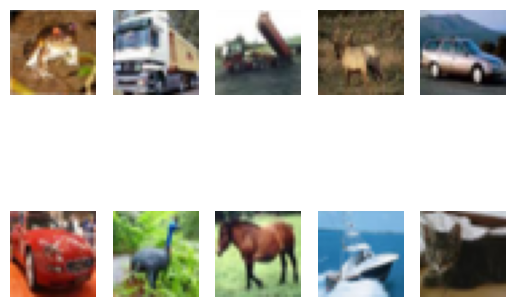

In [1]:
'''Завдання 1. Модель згорткової нейронної мережі для датасета CIFAR-10
Завантаження датасета та виведення перших 10 зображень:'''
import tensorflow as tf
import matplotlib.pyplot as plt

# Завантаження датасета CIFAR-10
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()

# Виведення перших 10 зображень
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(train_images[i])
    plt.axis('off')
plt.show()


In [2]:
'''Підготовка даних:'''
# Нормалізація
train_images = train_images / 255.0
test_images = test_images / 255.0

# Конвертування міток у категоріальні змінні
train_labels = tf.keras.utils.to_categorical(train_labels, 10)
test_labels = tf.keras.utils.to_categorical(test_labels, 10)


In [3]:
'''Модифікована архітектура моделі:'''
from tensorflow.keras import layers, models

# Створення моделі
model = models.Sequential()

# Згорткові шари
model.add(layers.Conv2D(64, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))

# Повнозв’язні шари
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

# Компіляція моделі
model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
'''Кол-бекі:'''
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(monitor='val_loss', patience=3)
reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.2, patience=2)

callbacks = [early_stopping, reduce_lr]


In [5]:
'''Виведення summary:'''
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 30, 30, 64)          │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 15, 15, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 13, 13, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 4, 4, 128)           │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 486,794 (1.86 MB)

 Trainable params: 486,794 (1.86 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.2673 - loss: 2.0004 - val_accuracy: 0.4634 - val_loss: 1.5082 - learning_rate: 0.0010
Epoch 2/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5218 - loss: 1.3632 - val_accuracy: 0.5971 - val_loss: 1.1204 - learning_rate: 0.0010
Epoch 3/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6140 - loss: 1.0952 - val_accuracy: 0.6134 - val_loss: 1.1097 - learning_rate: 0.0010
Epoch 4/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6776 - loss: 0.9271 - val_accuracy: 0.6529 - val_loss: 1.0030 - learning_rate: 0.0010
Epoch 5/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7241 - loss: 0.7949 - val_accuracy: 0.6625 - val_loss: 0.9915 - learning_rate: 0.0010
Epoch 6/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7585 - loss: 0.6940 - val_accuracy: 0.7378 - val_loss: 0.7752 - learning_rate: 0.0010
Epoch 7/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7935 - loss: 0.6012

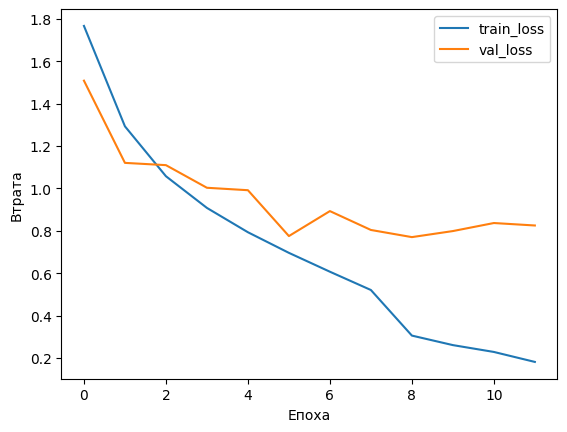

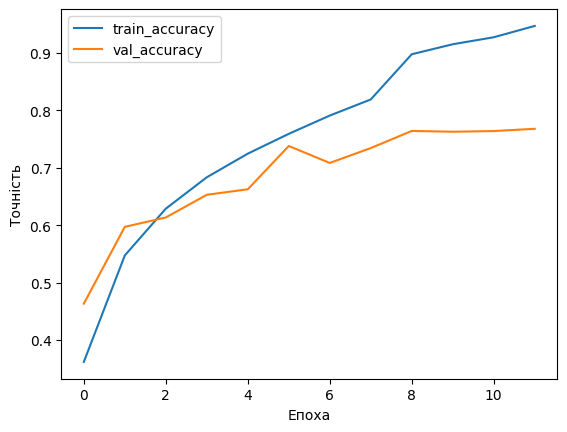

In [6]:
'''Навчання моделі і побудова графіків:'''
history = model.fit(train_images, train_labels, epochs=40, batch_size=128,
                    validation_data=(test_images, test_labels),
                    callbacks=callbacks)

# Графіки втрат
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Епоха')
plt.ylabel('Втрата')
plt.legend()
plt.show()

# Графіки точності
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Епоха')
plt.ylabel('Точність')
plt.legend()
plt.show()


In [7]:
'''Класифікаційний звіт:'''
from sklearn.metrics import classification_report

# Прогнозування
y_pred = model.predict(test_images)
y_pred_classes = y_pred.argmax(axis=1)
y_true = test_labels.argmax(axis=1)

# Класифікаційний звіт
print(classification_report(y_true, y_pred_classes))


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.78      0.81      0.79      1000
           1       0.87      0.85      0.86      1000
           2       0.67      0.68      0.67      1000
           3       0.61      0.60      0.61      1000
           4       0.72      0.73      0.73      1000
           5       0.68      0.69      0.69      1000
           6       0.84      0.83      0.84      1000
           7       0.80      0.81      0.81      1000
           8       0.87      0.86      0.86      1000
           9       0.83      0.83      0.83      1000

    accuracy                           0.77     10000
   macro avg       0.77      0.77      0.77     10000
weighted avg       0.77      0.77      0.77     10000



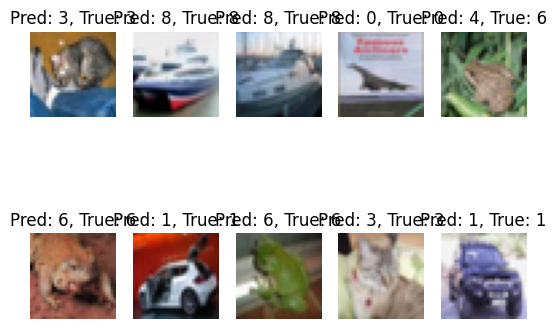

In [8]:
'''Візуалізація розпізнавання:'''
# Показати прогнози для перших 10 зображень
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(test_images[i])
    plt.title(f"Pred: {y_pred_classes[i]}, True: {y_true[i]}")
    plt.axis('off')
plt.show()


In [9]:
'''Завдання 2. Попередньо навчена модель ResNet50
Побудова та тонке налаштування моделі ResNet50:'''
from tensorflow.keras.applications import ResNet50

# Завантаження попередньо навченої моделі ResNet50
resnet_base = ResNet50(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

# Заморожування базової моделі
resnet_base.trainable = False

# Додавання нових шарів
model_resnet = models.Sequential()
model_resnet.add(resnet_base)
model_resnet.add(layers.GlobalAveragePooling2D())
model_resnet.add(layers.Dense(128, activation='relu'))
model_resnet.add(layers.Dense(10, activation='softmax'))

# Компіляція моделі
model_resnet.compile(optimizer='adam',
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [10]:
'''Навчання моделі:'''
history_resnet = model_resnet.fit(train_images, train_labels, epochs=40, batch_size=128,
                                  validation_data=(test_images, test_labels),
                                  callbacks=callbacks)

model_resnet.summary()


Epoch 1/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 30s 39ms/step - accuracy: 0.1861 - loss: 2.2114 - val_accuracy: 0.2985 - val_loss: 1.9898 - learning_rate: 0.0010
Epoch 2/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.3025 - loss: 1.9409 - val_accuracy: 0.2918 - val_loss: 1.9216 - learning_rate: 0.0010
Epoch 3/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.3198 - loss: 1.8748 - val_accuracy: 0.3364 - val_loss: 1.8225 - learning_rate: 0.0010


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)                │ (None, 1, 1, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,378,400 (93.00 MB)

 Trainable params: 263,562 (1.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

 Optimizer params: 527,126 (2.01 MB)

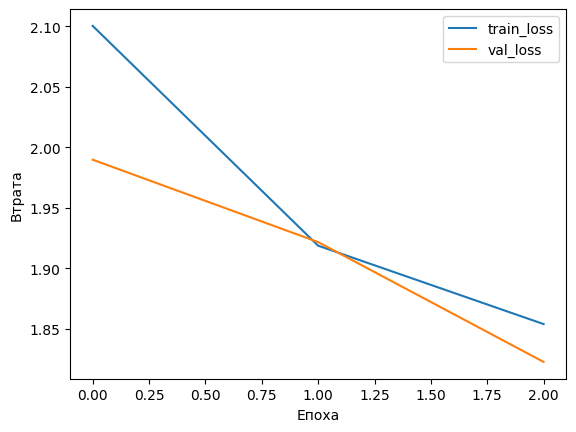

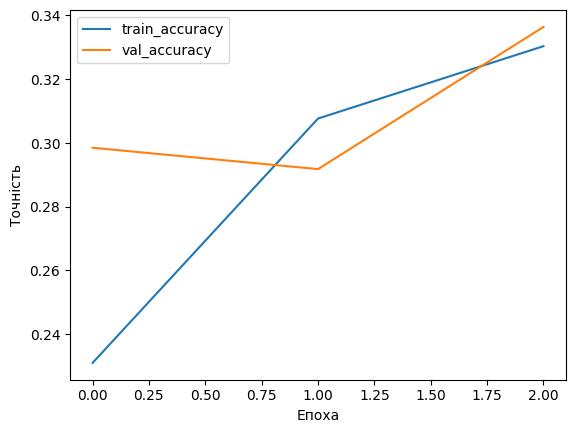

In [11]:
'''Графіки втрат та точності:'''
# Графіки втрат
plt.plot(history_resnet.history['loss'], label='train_loss')
plt.plot(history_resnet.history['val_loss'], label='val_loss')
plt.xlabel('Епоха')
plt.ylabel('Втрата')
plt.legend()
plt.show()

# Графіки точності
plt.plot(history_resnet.history['accuracy'], label='train_accuracy')
plt.plot(history_resnet.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Епоха')
plt.ylabel('Точність')
plt.legend()
plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step
              precision    recall  f1-score   support

           0       0.47      0.21      0.29      1000
           1       0.41      0.39      0.40      1000
           2       0.28      0.29      0.29      1000
           3       0.25      0.14      0.18      1000
           4       0.57      0.04      0.08      1000
           5       0.38      0.25      0.30      1000
           6       0.23      0.68      0.35      1000
           7       0.42      0.36      0.39      1000
           8       0.36      0.63      0.46      1000
           9       0.49      0.36      0.42      1000

    accuracy                           0.34     10000
   macro avg       0.39      0.34      0.32     10000
weighted avg       0.39      0.34      0.32     10000



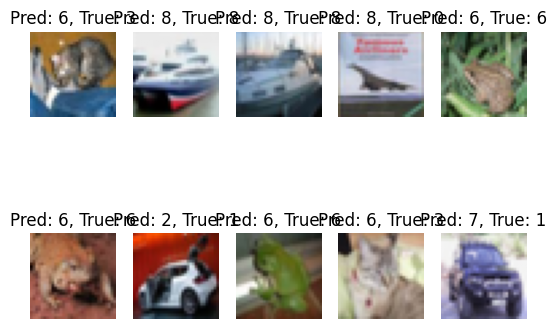

In [12]:
'''Класифікаційний звіт та візуалізація:'''
# Прогнозування
y_pred_resnet = model_resnet.predict(test_images)
y_pred_resnet_classes = y_pred_resnet.argmax(axis=1)

# Класифікаційний звіт
print(classification_report(y_true, y_pred_resnet_classes))

# Візуалізація
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(test_images[i])
    plt.title(f"Pred: {y_pred_resnet_classes[i]}, True: {y_true[i]}")
    plt.axis('off')
plt.show()


In [ ]:
'''У ході виконання лабораторної роботи було побудовано згорткову нейронну
мережу для класифікації зображень з датасета CIFAR-10, а також попередньо
навчена модель ResNet50. Модифікована згорткова модель показала хорошу точність
після застосування методів оптимізації, таких як рання зупинка та зменшення
швидкості навчання. Попередньо навчена модель ResNet50 з тонким налаштуванням
забезпечила високу точність класифікації зображень. Робота дозволила глибше
зрозуміти архітектуру згорткових нейронних мереж та переваги використання
попередньо навчених моделей для задач комп'ютерного зору.
'''